In [2]:
import sys
import os
from neuron import h, gui

# Load mechanisms
# h.nrn_load_dll("/Users/sandek/Desktop/187610master/arm64/libnrnmech.dylib")

# Move to folder with init_cell.py and SWC
os.chdir("/Users/sandek/kws/CA1Sim")
sys.path.append(os.getcwd())

from kws_init_cell import init_cell

cell = init_cell()

from kws_spines_analysis import count_spines
from kws_branch_selection import filter_by_length

# spine analysis
stats = count_spines(cell)
print(stats)

# branch selection
long_apicals = filter_by_length(cell, min_length=100, region="apical")
print(long_apicals)

import os

{'<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal5': {'length': 29.816485032195892, 'necks': 0, 'heads': 0}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal6': {'length': 15.492185540328848, 'necks': 7, 'heads': 7}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal7': {'length': 94.78055988237598, 'necks': 178, 'heads': 178}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal8': {'length': 4.835283517708445, 'necks': 12, 'heads': 12}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal9': {'length': 82.419622194081, 'necks': 164, 'heads': 164}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal10': {'length': 94.20602910222745, 'necks': 172, 'heads': 172}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal11': {'length': 3.140343913339536, 'necks': 1, 'heads': 1}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal12': {'length': 74.78600580062319, 'necks': 123, 'heads': 123}, '<specify_cells.CA1_Pyr object at 0x1050d31f0>.basal13': {'length': 92.15876898304795, 'ne

In [6]:
CELL_TYPES = {
    "WT": {"global_prune": 0.0, "plaque_fraction": 0.0, "select_fraction": 1.0}, # corrected
}

# same simulation loop, but only for WT
# collect results in a list of dicts
new_results = []

for trial in range(100):
    print(trial)
    for i in (1, 2, 3):
        # init WT
        cell_wt = init_cell()
        # delete_fraction_of_spines_per_branch(cell_wt, CELL_TYPES["WT"]["global_prune"])

        sec_node_wt = None
        for sec_node in cell_wt.apical:
            if sec_node.sec.name().endswith("apical131"):
                sec_node_wt = sec_node
                break

        for n in [20]:
            # delete_fraction_from_branch_in_one_third(sec_node_wt, i, CELL_TYPES["WT"]["plaque_fraction"])
            spines = random.sample(sec_node_wt.spines, n)

            t, v_soma, v_dend, _ = simulate_and_record(cell_wt, sec_node_wt, spines)

            new_results.append({
                "trial": trial,
                "third": i,
                "n": n,
                "cell_type": "WT",
                "soma_peak": max(v_soma) - v_soma[0],
                "dend_peak": max(v_dend) - v_dend[0]
            })

df_new = pd.DataFrame(new_results)


0
Spike count detected on <specify_cells.CA1_Pyr object at 0x1375578b0>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16993c0d0>.apical131: 1
1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16993c0d0>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131: 1
2
Spike count detected on <specify_cells.CA1_Pyr object at 0x1696e3c10>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x1696e3c10>.apical131: 1
3
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x1696e3c10>.apical131: 1
Spike count detected on <specify_cells.CA1_Pyr object at 0x16bc99840>.apical131

NameError: name 'pd' is not defined

In [ ]:
# forgot to import this earlier
import pandas as pd  

# turn results into a dataframe
df_new = pd.DataFrame(new_results)

# quick check
print(df_new.shape)
print(df_new.head())

# load the old results
df_old = pd.read_csv("100trials_peak_values.csv")

# combine with new WT runs
df_all = pd.concat([df_old, df_new], ignore_index=True)

# save back to csv
df_all.to_csv("100trials_peak_values_combined.csv", index=False)

print("Merged shape:", df_all.shape)
print("Cell types present:", df_all["cell_type"].unique())

df_old = pd.read_csv("100trials_peak_values.csv")
print(df_old.columns)



(300, 6)
   trial  third   n cell_type  soma_peak  dend_peak
0      0      1  20        WT   3.694485  65.016285
1      0      2  20        WT   4.566898  65.405875
2      0      3  20        WT   4.658475  66.320448
3      1      1  20        WT   4.459074  65.650779
4      1      2  20        WT   4.026220  65.149098


In [13]:
import pandas as pd  

# Just load the merged file you already created
df_all = pd.read_csv("100trials_peak_values_combined.csv")

# Quick checks
print("Final shape:", df_all.shape)
print("Cell types present:", df_all["cell_type"].unique())
print(df_all.head())


Final shape: (2400, 5)


KeyError: 'cell_type'

In [10]:
import pandas as pd  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_all = pd.read_csv("100trials_peak_values_combined.csv")

# --- reshape results from df_all into nested dict ---
def reshape_results_for_plot(df):
    reshaped = {}
    for n in df["spines"].unique():
        reshaped[n] = {}
        for third in sorted(df["branch_third"].unique()):
            reshaped[n][third] = {}
            for cond in ["WT", "plaque", "SAAeq", "SAAred"]:
                for comp in ["soma", "dend"]:
                    vals = df[
                        (df["spines"] == n) &
                        (df["branch_third"] == third) &
                        (df["condition"] == cond) &
                        (df["compartment"] == comp)
                    ]["peak_voltage"].values
                    reshaped[n][third][f"{cond}_{comp}"] = vals
    return reshaped

reshaped_results = reshape_results_for_plot(df_all)

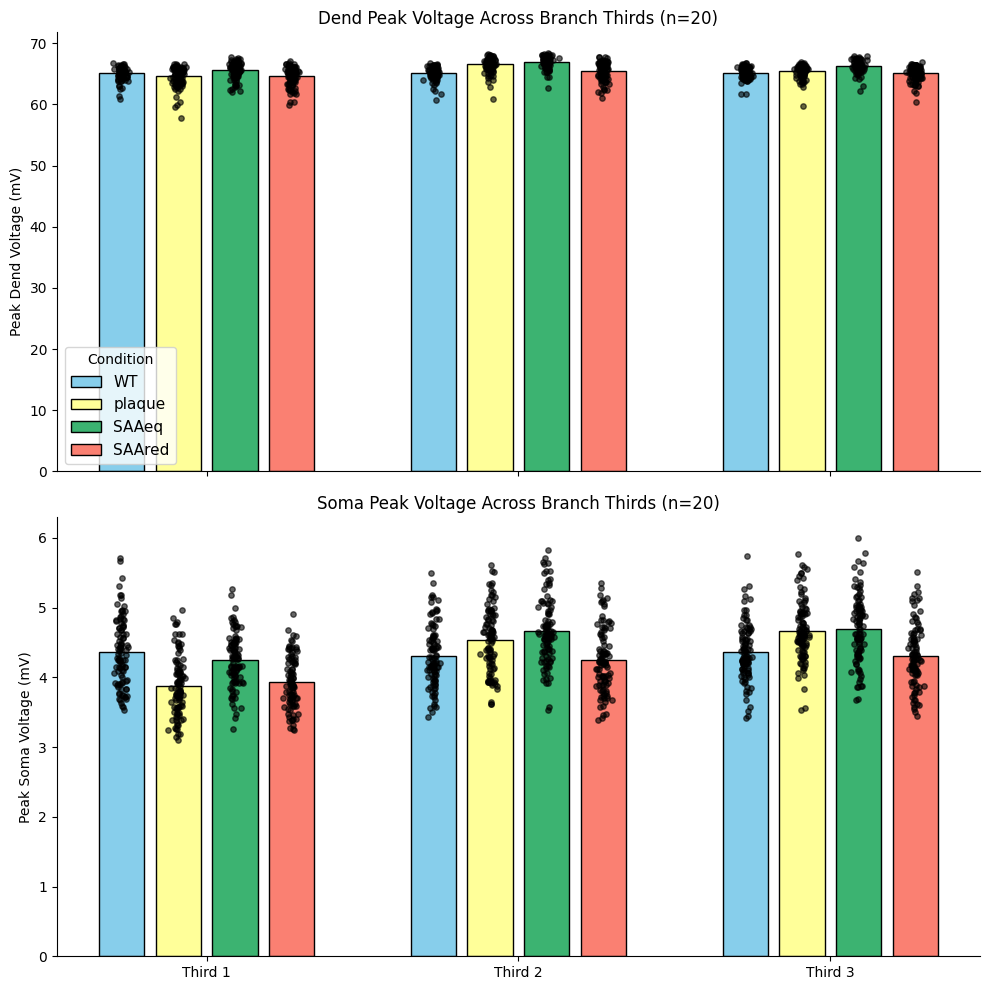

In [11]:

# --- plotting ---
conditions = ["WT", "plaque", "SAAeq", "SAAred"]
thirds = [1, 2, 3]
bar_colors = {
    "WT": "skyblue",
    "plaque": "#FFFF99",
    "SAAeq": "mediumseagreen",
    "SAAred": "salmon"
}

n = 20  # plotting this spine count
group_spacing = 1.5

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
compartments = ["dend", "soma"]

for ax, comp in zip(axes, compartments):
    x_map, x, bar_means, bar_colors_list = {}, [], [], []
    x_pos = 0

    for third in thirds:
        for cond in conditions:
            vals = reshaped_results[n][third].get(f"{cond}_{comp}", [])
            if len(vals) == 0:
                continue
            bar_means.append(np.mean(vals))
            bar_colors_list.append(bar_colors[cond])
            x.append(x_pos)
            x_map[(third, cond)] = x_pos
            x_pos += 1
        x_pos += group_spacing

    # plot bars
    ax.bar(x, bar_means, color=bar_colors_list, edgecolor="black")

    # jittered points
    for third in thirds:
        for cond in conditions:
            xpos = x_map.get((third, cond))
            if xpos is None:
                continue
            vals = reshaped_results[n][third].get(f"{cond}_{comp}", [])
            jitter = np.random.normal(0, 0.05, size=len(vals))
            ax.scatter(np.full(len(vals), xpos) + jitter, vals,
                       color="black", s=15, alpha=0.6)

    # formatting
    ax.set_xticks([
        np.mean([x_map[(third, cond)] for cond in conditions if (third, cond) in x_map])
        for third in thirds
    ])
    ax.set_xticklabels([f"Third {i}" for i in thirds])
    ax.set_ylabel(f"Peak {comp.capitalize()} Voltage (mV)")
    ax.set_title(f"{comp.capitalize()} Peak Voltage Across Branch Thirds (n={n})")
    ax.spines[["right", "top"]].set_visible(False)

# legend only once
legend_elements = [Patch(facecolor=bar_colors[c], edgecolor="black", label=c) for c in conditions]
axes[0].legend(handles=legend_elements, fontsize=11, title="Condition")

plt.tight_layout()
plt.show()


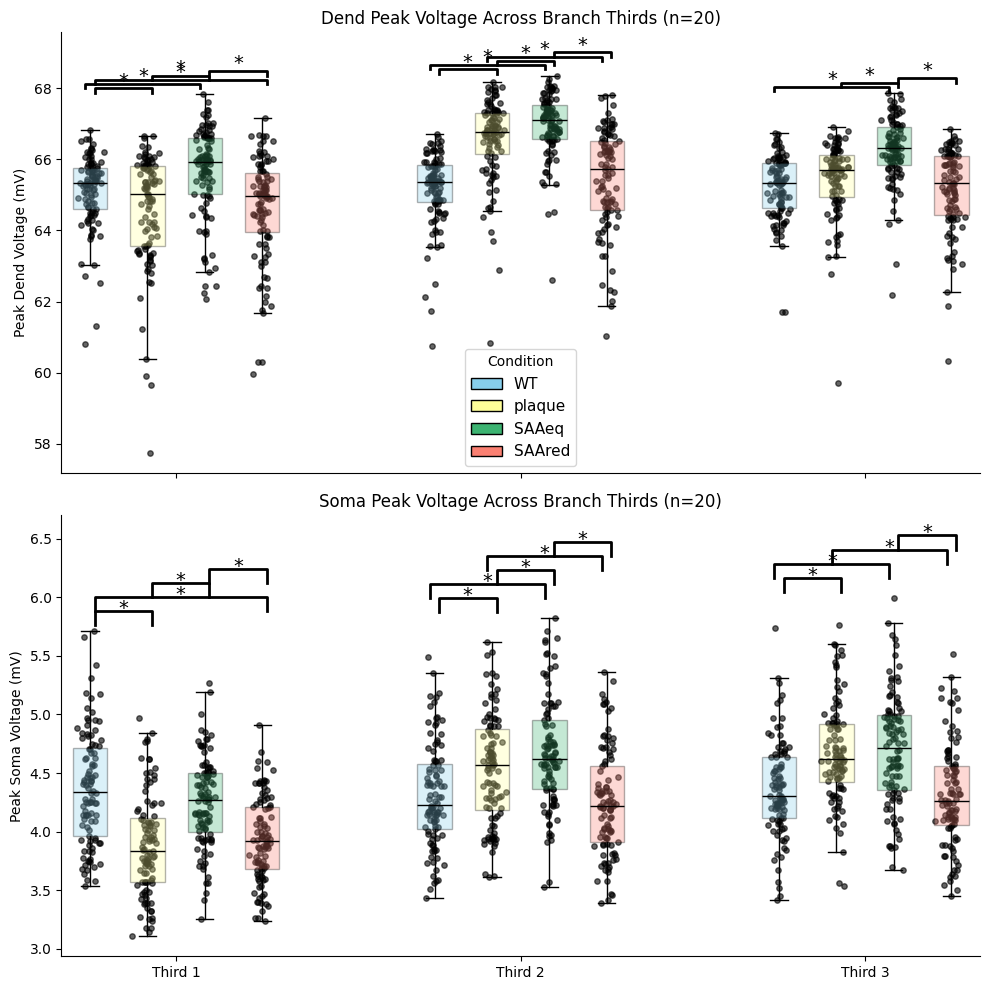

In [12]:
# build reshaped dict
reshaped_results = reshape_results_for_plot(df_all)
n = 20


# --- plotting setup ---
conditions = ["WT", "plaque", "SAAeq", "SAAred"]
thirds = [1, 2, 3]
bar_colors = {
    "WT": "skyblue",
    "plaque": "#FFFF99",
    "SAAeq": "mediumseagreen",
    "SAAred": "salmon"
}
compartments = ["dend", "soma"]
n = 20  # spine count
group_spacing = 2

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

def blend_colors(color1, color2, alpha=0.5):
    """Blend two matplotlib colors by averaging their RGB values."""
    rgb1 = np.array(mcolors.to_rgb(color1))
    rgb2 = np.array(mcolors.to_rgb(color2))
    return tuple(alpha*rgb1 + (1-alpha)*rgb2)

def add_significance(ax, x_map, data, third, comp,
                     base_offset=0.05, step_offset=0.12, x_shift=0.08):
    # find max y across all groups for this third+comp
    max_y = max([np.max(data[n][third][f"{c}_{comp}"]) for c in conditions])
    offset_tracker = 0

    for i, cond1 in enumerate(conditions):
        for j, cond2 in enumerate(conditions[i+1:]):
            vals1 = data[n][third][f"{cond1}_{comp}"]
            vals2 = data[n][third][f"{cond2}_{comp}"]
            _, pval = ttest_ind(vals1, vals2, equal_var=False)
            if pval < 0.05:
                shift = (-1)**j * x_shift
                x1 = x_map[(third, cond1)] + shift
                x2 = x_map[(third, cond2)] + shift
                y = max_y + base_offset + step_offset * offset_tracker
                offset_tracker += 1

                ax.plot([x1, x1, x2, x2],
                        [y, y+step_offset, y+step_offset, y],
                        color='black', lw=2)
                ax.text((x1+x2)/2, y + step_offset*0.5, "*",
                        ha='center', va='bottom', fontsize=14, color='black')

# --- main plotting loop ---
for ax, comp in zip(axes, compartments):
    x_map, box_data, box_positions = {}, [], []
    x_pos = 0

    for third in thirds:
        for cond in conditions:
            vals = reshaped_results[n][third][f"{cond}_{comp}"]
            box_data.append(vals)
            box_positions.append(x_pos)
            x_map[(third, cond)] = x_pos
            x_pos += 1
        x_pos += group_spacing

    # boxplots
    bplot = ax.boxplot(box_data, positions=box_positions, widths=0.6,
                       patch_artist=True, showfliers=False,
                       medianprops=dict(color='black'))
    for patch, color in zip(bplot['boxes'],
                            [bar_colors[c] for c in conditions] * len(thirds)):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)

    # jitter points
    for third in thirds:
        for cond in conditions:
            xpos = x_map[(third, cond)]
            vals = reshaped_results[n][third][f"{cond}_{comp}"]
            jitter = np.random.normal(0, 0.08, size=len(vals))
            ax.scatter(np.full(len(vals), xpos) + jitter,
                       vals, color="black", s=15, alpha=0.6)

    # significance
    for third in thirds:
        add_significance(ax, x_map, reshaped_results, third, comp)

    ax.set_xticks([np.mean([x_map[(third, cond)] for cond in conditions]) for third in thirds])
    ax.set_xticklabels([f"Third {i}" for i in thirds])
    ax.set_ylabel(f"Peak {comp.capitalize()} Voltage (mV)")
    ax.set_title(f"{comp.capitalize()} Peak Voltage Across Branch Thirds (n={n})")
    ax.spines[["right", "top"]].set_visible(False)

# legend
legend_elements = [Patch(facecolor=bar_colors[c], edgecolor="black", label=c) for c in conditions]
axes[0].legend(handles=legend_elements, fontsize=11, title="Condition")

plt.tight_layout()
plt.show()
